In [2]:
import pandas as pd
import numpy as np

In [3]:
df_raw=pd.read_csv("/content/customer_shopping_messy.csv")

In [4]:
df_raw.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28.0,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21.0,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20.0,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66.0,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53.0,Books,4,60.60,Cash,24/10/2021,Kanyon


In [5]:
df_raw.shape

(99957, 10)

In [6]:
df_raw.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,300
category,0
quantity,0
price,200
payment_method,0
invoice_date,0
shopping_mall,0


In [7]:
df_raw.duplicated().sum()

np.int64(475)

In [8]:
df_raw.dtypes

,0
invoice_no,object
customer_id,object
gender,object
age,float64
category,object
quantity,int64
price,float64
payment_method,object
invoice_date,object
shopping_mall,object


In [9]:
print(df_raw['gender'].unique())
print(df_raw['category'].unique())
print(df_raw['payment_method'].unique())
print(df_raw['shopping_mall'].unique())

['Female' 'Male' 'FEMALE' 'male']
['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir' 'SHOES' 'clothing']
['Credit Card' 'Debit Card' 'Cash' 'credit card' 'CASH']
['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center' '  Emaar Square Mall  ' '  Mall of Istanbul  '
 '  Metrocity  ' '  Forum Istanbul  ' '  Metropol AVM  '
 '  Zorlu Center  ' '  Kanyon  ' '  Viaport Outlet  ' '  Istinye Park  '
 '  Cevahir AVM  ']


In [10]:
print(f"Age max: {df_raw['age'].max()}")
print(f"Age min: {df_raw['age'].min()}")
print(f"Age mean: {df_raw['age'].mean()}")
print(f"Price max: {df_raw['price'].max()}")
print(f"Price min: {df_raw['price'].min()}")

Age max: 999.0
Age min: 18.0
Age mean: 44.85906659843263
Price max: 5250.0
Price min: -99.0


In [11]:
df_clean = df_raw.copy()
df_clean.shape

(99957, 10)

In [12]:
df_clean['gender'] = df_clean['gender'].str.strip().str.lower()
df_clean['category'] = df_clean['category'].str.strip().str.lower()
df_clean['payment_method'] = df_clean['payment_method'].str.strip().str.lower()
df_clean['shopping_mall'] = df_clean['shopping_mall'].str.strip().str.lower()

In [13]:
df_clean.duplicated().sum()

np.int64(478)

In [14]:
df_clean = df_clean.drop_duplicates()
df_clean.shape

(99479, 10)

In [15]:
df_clean = df_clean[df_clean['age'] <= 100]
df_clean['age'].max()


69.0

In [16]:
df_clean = df_clean[df_clean['price'] > 0]
df_clean['price'].min()

5.23

In [17]:
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].mean())
df_clean['age'].isnull().sum()

np.int64(0)

In [18]:
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].mean())
df_clean['price'].isnull().sum()


np.int64(0)

In [19]:
df_clean['invoice_date'] = pd.to_datetime(df_clean['invoice_date'], format='mixed', dayfirst=True)
df_clean['invoice_date'].dtype

dtype('<M8[ns]')

In [20]:
df_clean['age'] = df_clean['age'].astype(int)
df_clean['age'].dtype

dtype('int64')

In [21]:
print(f"Shape: {df_clean.shape}")
print(f"Nulls:\n{df_clean.isnull().sum()}")
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(f"Age max: {df_clean['age'].max()}")
print(f"Price min: {df_clean['price'].min()}")
print(f"Gender unique: {df_clean['gender'].unique()}")
print(f"Category unique: {df_clean['category'].unique()}")
print(f"Payment unique: {df_clean['payment_method'].unique()}")
print(f"Date type: {df_clean['invoice_date'].dtype}")

Shape: (98733, 10)
Nulls:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64
Duplicates: 4
Age max: 69
Price min: 5.23
Gender unique: ['female' 'male']
Category unique: ['clothing' 'shoes' 'books' 'cosmetics' 'food & beverage' 'toys'
 'technology' 'souvenir']
Payment unique: ['credit card' 'debit card' 'cash']
Date type: datetime64[ns]


In [22]:
df_clean = df_clean.drop_duplicates()
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(f"Final Shape: {df_clean.shape}")

Duplicates: 0
Final Shape: (98729, 10)


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean['age_normalized'] = scaler.fit_transform(df_clean[['age']])
df_clean['price_normalized'] = scaler.fit_transform(df_clean[['price']])

df_clean[['age', 'age_normalized', 'price', 'price_normalized']].head()

,age,age_normalized,price,price_normalized
0,28,0.196078,1500.40,0.285078
1,21,0.058824,1800.51,0.342299
2,20,0.039216,300.08,0.056218
3,66,0.941176,3000.85,0.571163
4,53,0.686275,60.60,0.010557


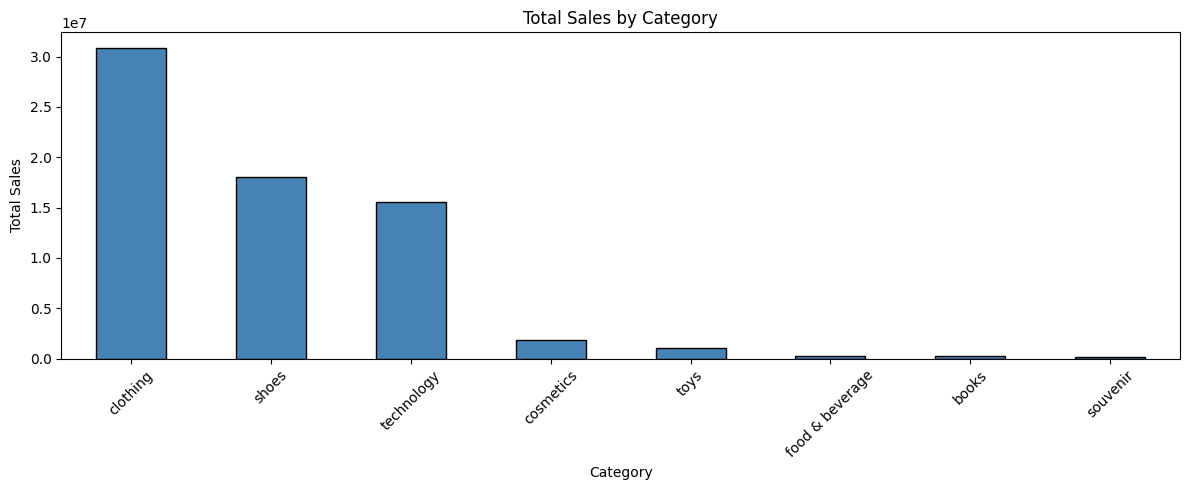

In [24]:
import matplotlib.pyplot as plt

category_sales = df_clean.groupby('category')['price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
category_sales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

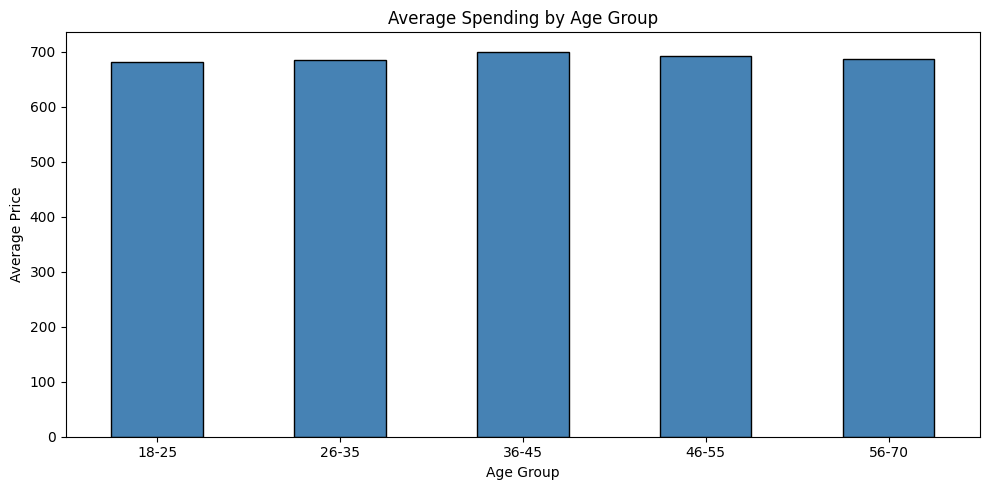

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[0, 25, 35, 45, 55, 70],
                                labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

age_spending = df_clean.groupby('age_group', observed=True)['price'].mean()

plt.figure(figsize=(10, 5))
age_spending.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

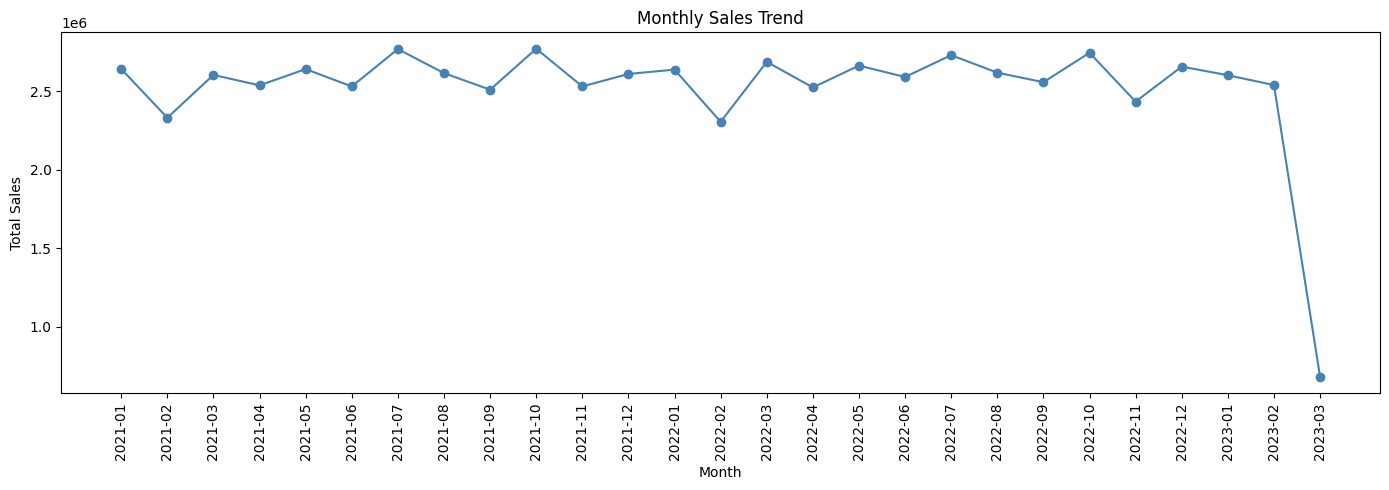

In [27]:
df_clean['month'] = df_clean['invoice_date'].dt.month
df_clean['year'] = df_clean['invoice_date'].dt.year

monthly_sales = df_clean.groupby(['year', 'month'])['price'].sum().reset_index()
monthly_sales['period'] = monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['period'], monthly_sales['price'], marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

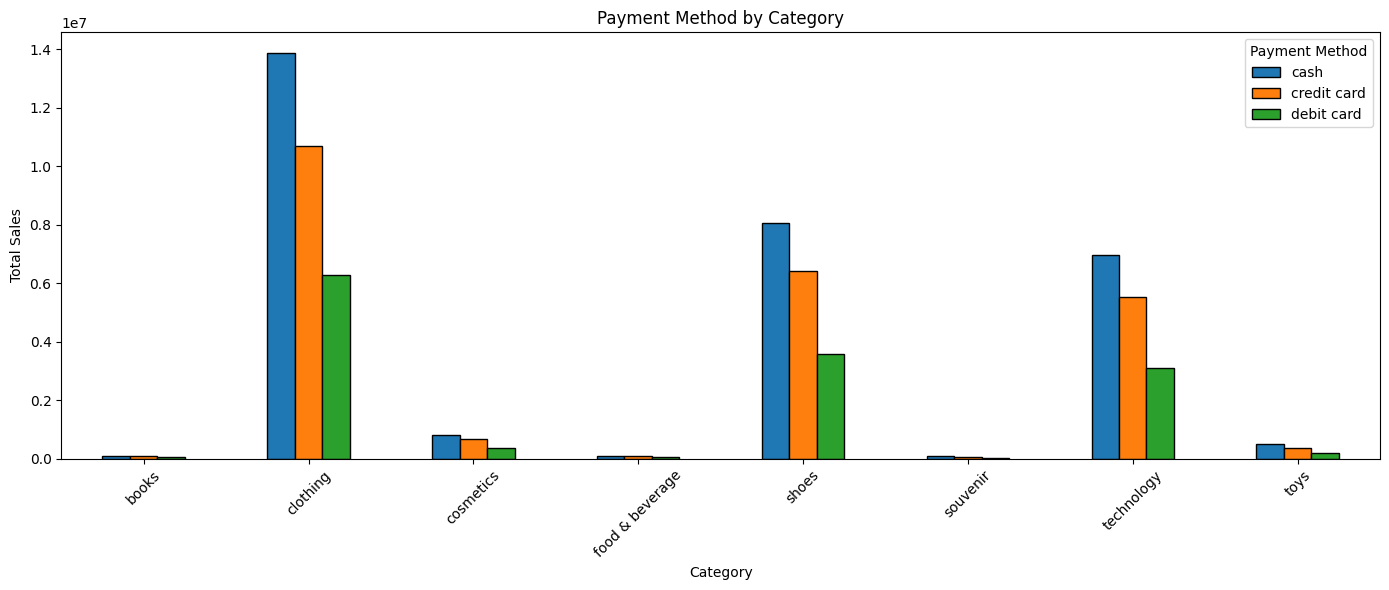

In [28]:
payment_category = df_clean.groupby(['category', 'payment_method'])['price'].sum().unstack()

payment_category.plot(kind='bar', figsize=(14, 6), edgecolor='black')
plt.title('Payment Method by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Payment Method')
plt.tight_layout()
plt.show()

In [29]:
df_clean.to_csv('customer_analytics_clean.csv', index=False)

In [30]:
print(f"✅ Clean data saved!")
print(f"Total rows: {len(df_clean)}")
print(f"Total columns: {len(df_clean.columns)}")

✅ Clean data saved!
Total rows: 98729
Total columns: 15


In [31]:
from google.colab import files
files.download('customer_analytics_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>